--- Step 1: Data Splitting ---
Train set size:      364
Validation set size: 91
Test set size:       114

--- Step 2: Training XGBoost Configurations ---

Training Config 1 (Standard) with LR=0.1...
--> Stopped at tree #35 (Best Val LogLoss: 0.1570)

Training Config 2 (Fast/Aggressive) with LR=0.3...
--> Stopped at tree #31 (Best Val LogLoss: 0.1458)

Training Config 3 (Slow/Precise) with LR=0.03...
--> Stopped at tree #130 (Best Val LogLoss: 0.1535)

--- Step 3: Visualizing Learning Curves ---


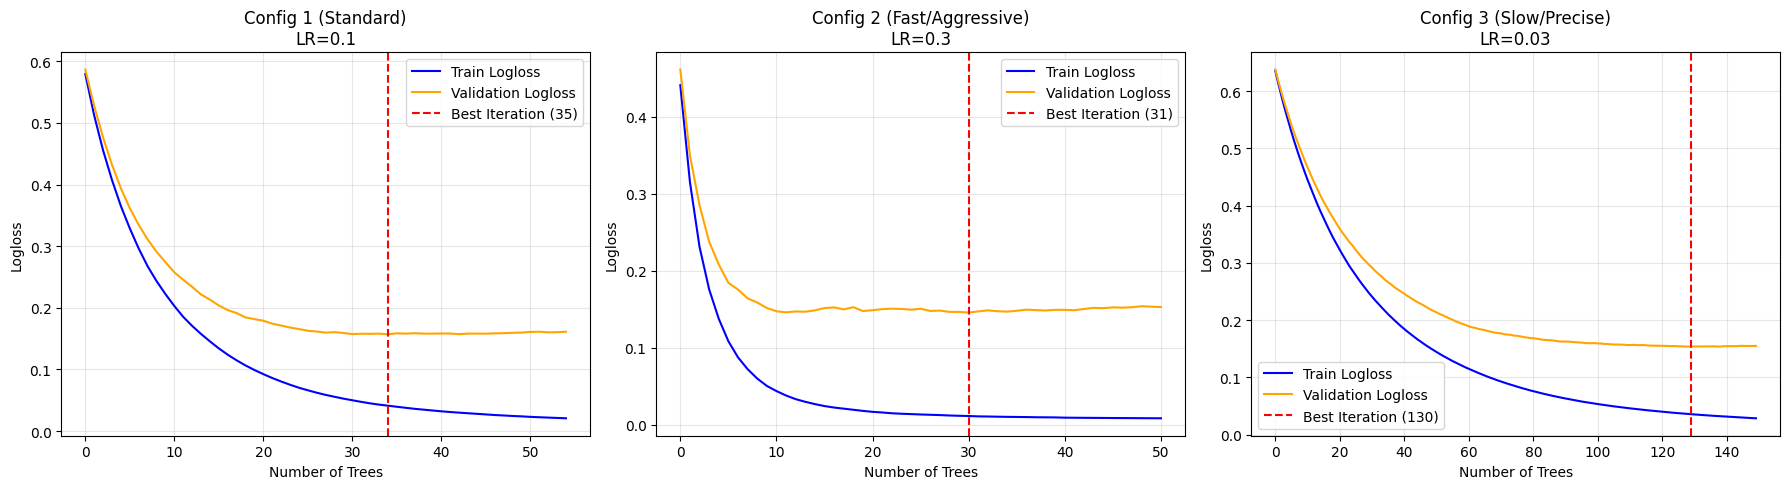


--- Step 4: Final Test Set Comparison ---
Training Model without Validation Set (No early stopping)...


,Model,Test Accuracy,Trees Used
0,Config 1 (Standard),0.938596,35
1,Config 2 (Fast/Aggressive),0.938596,31
2,Config 3 (Slow/Precise),0.938596,130
3,No Validation Set (Overfit Risk),0.947368,800


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# Step 1: Data Setup (Train/Validation/Test Split)
# ==========================================
print("--- Step 1: Data Splitting ---")
data = load_breast_cancer()
X, y = data.data, data.target

# 1. First split: Separate out the 20% TEST set (Untouched until the very end)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Second split: Separate the remaining 80% into TRAIN and VALIDATION
# We take 20% of the training data to be our validation set
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

print(f"Train set size:      {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Test set size:       {X_test.shape[0]}")

# ==========================================
# Step 2: Training 3 different configurations
# ==========================================
print("\n--- Step 2: Training XGBoost Configurations ---")

# We will store the models and their evaluation results to plot them later
models = {}
eval_results = {}

# Define 3 configurations to test the impact of learning rate
configs = {
    "Config 1 (Standard)": {"learning_rate": 0.1, "n_estimators": 800},
    "Config 2 (Fast/Aggressive)": {"learning_rate": 0.3, "n_estimators": 800},
    "Config 3 (Slow/Precise)": {"learning_rate": 0.03, "n_estimators": 800},
}

for name, params in configs.items():
    print(f"\nTraining {name} with LR={params['learning_rate']}...")
    
    # Initialize the model
    # NEW FIX: early_stopping_rounds is now placed here!
    model = XGBClassifier(
        n_estimators=params['n_estimators'],
        learning_rate=params['learning_rate'],
        max_depth=4,
        random_state=42,
        eval_metric="logloss", 
        early_stopping_rounds=20 
    )
    
    # Fit the model
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)], # Monitor both Train and Val
        verbose=False # Set to True if you want to see every single tree printed!
    )
    
    # Store results
    models[name] = model
    eval_results[name] = model.evals_result()
    print(f"--> Stopped at tree #{model.best_iteration + 1} (Best Val LogLoss: {model.best_score:.4f})")

# ==========================================
# Step 3: Plotting the Learning Curves
# ==========================================
print("\n--- Step 3: Visualizing Learning Curves ---")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, result) in enumerate(eval_results.items()):
    train_logloss = result["validation_0"]["logloss"]
    val_logloss = result["validation_1"]["logloss"]
    best_iter = models[name].best_iteration
    
    axes[i].plot(train_logloss, label="Train Logloss", color='blue')
    axes[i].plot(val_logloss, label="Validation Logloss", color='orange')
    axes[i].axvline(best_iter, color="r", linestyle="--", label=f"Best Iteration ({best_iter+1})")
    
    axes[i].set_title(f"{name}\nLR={configs[name]['learning_rate']}")
    axes[i].set_xlabel("Number of Trees")
    axes[i].set_ylabel("Logloss")
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# Step 4: Final Test Set Evaluation & Comparison
# ==========================================
print("\n--- Step 4: Final Test Set Comparison ---")

# Let's also train a model with NO validation set (Overfitting risk!)
print("Training Model without Validation Set (No early stopping)...")
model_no_val = XGBClassifier(n_estimators=800, learning_rate=0.1, max_depth=4, random_state=42)
# We train it on the FULL training data since we aren't holding out a validation set
model_no_val.fit(X_train_full, y_train_full) 

# Compare all models on the completely unseen TEST set
results = []

for name, model in models.items():
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results.append({"Model": name, "Test Accuracy": acc, "Trees Used": model.best_iteration + 1})

# Add the No-Validation model
preds_no_val = model_no_val.predict(X_test)
acc_no_val = accuracy_score(y_test, preds_no_val)
results.append({"Model": "No Validation Set (Overfit Risk)", "Test Accuracy": acc_no_val, "Trees Used": 800})

df_results = pd.DataFrame(results)
display(df_results)